In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

<h1>CUP - SVM</h1>
<p>Exploring the cup dataset with SVM.</p>
<hr/>

In [2]:
import importlib
import warnings
import numpy as np
from sklearn import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

import cup_common as cc
import svm_common as sc
import cross_common as cr
from cross_common import MEE,MSE,RMSE,MAE,R2

In [3]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [4]:
warnings.filterwarnings("ignore", category=ConvergenceWarning, append=True)

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [5]:
gamma_values = np.logspace(1, 1.8, 6)

# Note: The regularization parameter C is explored on a logarithmic scale over four orders of magnitude,
# from strong (0.1) to weak regularization (100), following standard practice for SVM hyperparameter tuning.
param_grid_default = [
    {  # custom
        "model__estimator__kernel": [cr.CustomRBFKernel(g) for g in gamma_values],
        "model__estimator__C": [1e-2, 1e0, 1e2, 1e4],
        "model__estimator__gamma": [1e-4, 1e-2, 1e0],
        "model__estimator__epsilon": [0.01, 0.1, 0.5],
    },
    # {  # linear
    #     "model__estimator__kernel": ["linear"],
    #     "model__estimator__C": [0.1, 1, 10, 100],
    #     "model__estimator__epsilon": [0.01, 0.05, 0.1, 0.2],
    # },
    {  # RBF
        "model__estimator__kernel": ["rbf"],
        "model__estimator__C": [3, 10, 30, 100],
        "model__estimator__gamma": ["scale", 0.1, 0.3, 1, 3],
        "model__estimator__epsilon": [0.1, 0.4, 0.8],
    },
    {  # Polynomial
        "model__estimator__kernel": ["poly"],
        "model__estimator__C": [0.1, 1, 10],
        "model__estimator__gamma": ["scale", 0.03, 0.1],
        "model__estimator__epsilon": [0.1, 0.4],
        "model__estimator__degree": [2, 3],
        "model__estimator__coef0": [0, 1],
    }
]

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(SVR()))
])

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,max),
}
the_metrics = metrics_dict.keys()
# ------------------------------------------

# Common scoring
default_metric = MEE
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


<h3>Data Loading</h3>

In [6]:
df_train, df_test = cc.load_set()

# The train set used for model selection
X_ts, y_ts = cc.prepare_dataset(df_test)

# Split the 500 labelled samples:
# - 80% development set for model selection and cross-validation
# - 20% internal test set for the final independent assessment
(
    X_tr, y_tr, # The train set
    X_internal_ts, y_internal_ts # The internal test set
 ) = (
    # by default 'prepare for hold out' split into 80% - 20%
    cc.prepare_dataset_for_hold_out(df_train,random_state=cc.INTERNAL_TEST_RANDOM_STATE)
)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,400,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [7]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.44424819946289
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-34.0255928  -36.09343338 -35.34489059 -35.34389114 -36.41343307]


<h3>Best Model</h3>

In [8]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = outer_cv,
    scoring = scoring,
    error_score="raise",
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gs.fit(X_tr, y_tr)

best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)


cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 348  splits: 5
Best params: {'model__estimator__C': 100, 'model__estimator__epsilon': 0.1, 'model__estimator__gamma': 3, 'model__estimator__kernel': 'rbf'}
Best score: -17.678397707374142
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', MultiOutputRegressor(estimator=SVR(C=100, gamma=3)))])


<h3>Learning Curve</h3>
<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

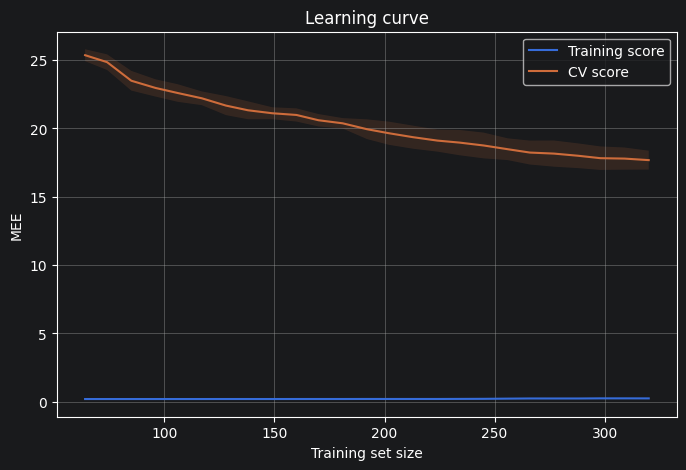

In [9]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [10]:
non_nested_runner = cr.SklearnRegressorRunner(gs)
non_nested_kf_result = cr.kfold(non_nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 17.4473
Validation MSE       | 102.6721
Validation MAE       | 7.6547
Validation RMSE      | 10.1327
Validation R2        | 0.6370
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 2, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 18.8295
Validation MSE       | 113.8895
Validation MAE       | 8.3030
Validation RMSE      | 10.6719
Validation R2        | 0.6435
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 3, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 17.6633
Validation MSE       | 103.6412
Validation MAE       | 7.6395
Validation RMSE    

In [11]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_kf_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -17.6784 ± 0.6903
Best CV func score: 17.6784 ± 0.6903


<h3>Nested Cross Validation</h3>

In [12]:
importlib.reload(cr)

outer_cv = outer_cv
inner_cv = cr.common_fold_strategy(n_split=3)

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_default,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
with warnings.catch_warnings():
    nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 320, val size: 80
Grid summary
----------------------------------------
Total model explored: 348  splits: 3
Best params: {'model__estimator__C': 100, 'model__estimator__epsilon': 0.1, 'model__estimator__gamma': 3, 'model__estimator__kernel': 'rbf'}
Best score: -18.94489142970856
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', MultiOutputRegressor(estimator=SVR(C=100, gamma=3)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 17.4473
Validation MSE       | 102.6721
Validation MAE       | 7.6547
Validation RMSE      | 10.1327
Validation R2        | 0.6370
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 2, train size: 320, val size: 80
Grid summary
----------------------------------------
Total model explored: 348  splits: 3
Best params: {'model__estimator__C': 30, 'model__estimator__epsilon': 0.1, 'model__est

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

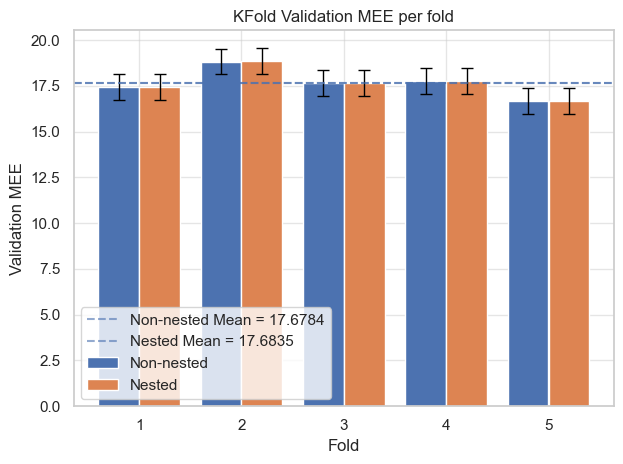

MEE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.277902,17.447305,17.169404
2,2.097952,18.855111,16.757160
3,0.199646,17.663322,17.463677
4,0.243572,17.771296,17.527724
5,0.252285,16.680602,16.428317
MEAN,0.614271,17.683527,17.069256
STD,0.742269,0.698911,0.420475


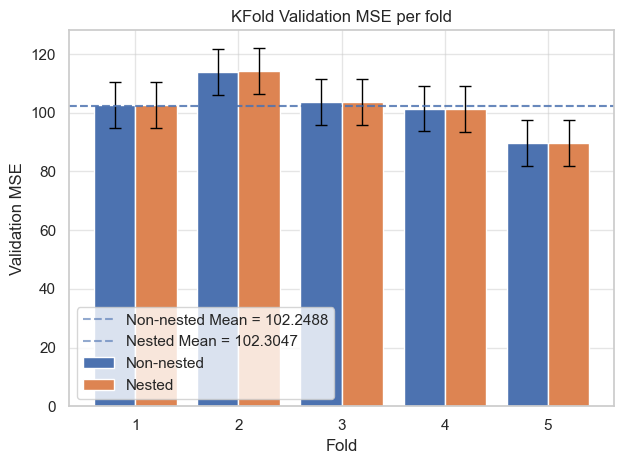

MSE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.210647,102.672057,102.461410
2,6.082969,114.169248,108.086280
3,0.009967,103.641238,103.631271
4,0.124125,101.365887,101.241762
5,0.191261,89.675192,89.483931
MEAN,1.323794,102.304724,100.980931
STD,2.380623,7.785559,6.195985


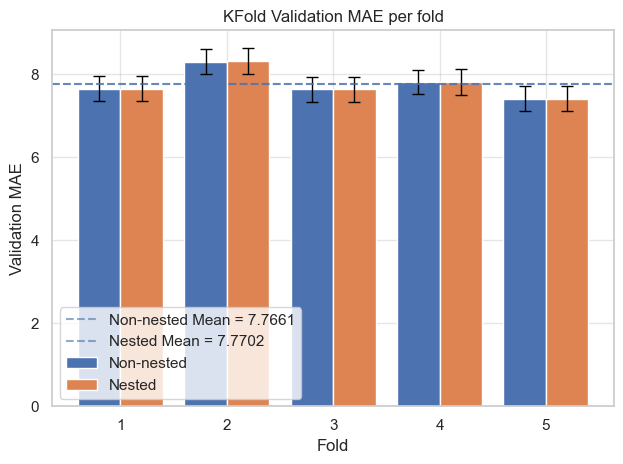

MAE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.119479,7.654701,7.535222
2,0.700248,8.323803,7.623555
3,0.099733,7.639537,7.539803
4,0.110895,7.818865,7.707970
5,0.112967,7.414344,7.301377
MEAN,0.228664,7.770250,7.541585
STD,0.235878,0.305251,0.135755


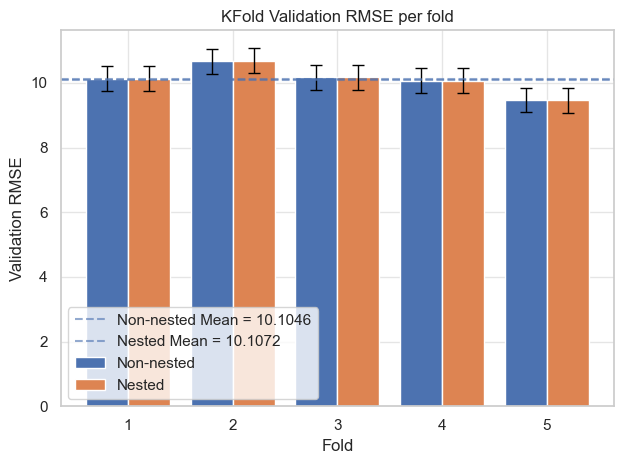

RMSE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.458963,10.132722,9.673759
2,2.466368,10.685001,8.218634
3,0.099835,10.180434,10.080599
4,0.352314,10.068063,9.715749
5,0.437334,9.469699,9.032365
MEAN,0.762963,10.107184,9.344221
STD,0.861209,0.386732,0.656214


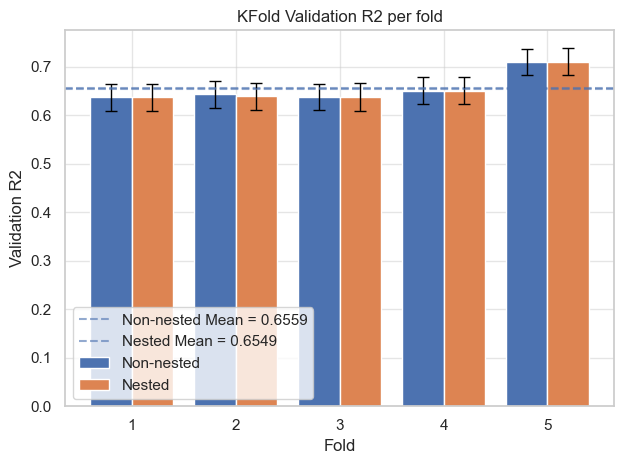

R2 TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.999158,0.636972,-0.362186
2,0.978808,0.638927,-0.339881
3,0.999967,0.637840,-0.362127
4,0.999400,0.650897,-0.348503
5,0.999112,0.710050,-0.289061
MEAN,0.995289,0.654937,-0.340352
STD,0.008246,0.028018,0.027012


In [13]:
for metric in the_metrics:
    cr.plot_kfold_metric([(non_nested_kf_result, "Non-nested"), (nested_result, "Nested")], metric)
    print(f"{metric.upper()} TR vs VL from KFold Nested results")
    display(cr.kfold_summary(nested_result, use=metric))

<h3>Bootstrap Variance</h3>
<p>Bootstrap is applied to approximate the sampling distribution of the estimator when only a finite dataset is available. By generating multiple resampled datasets, we can estimate variance, assess model stability, and better understand generalization behavior.</p>

In [14]:
importlib.reload(cr)
bootstrap_samples = 100
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}

with warnings.catch_warnings():
    bootstrap_scores = cr.bootstrap_out_of_bag_scores(non_nested_runner, X_tr, y_tr, samples, metrics_dict,bootstrap_params=bootstrap_params)


In [15]:
importlib.reload(cr)
cr.aggregate_scores(bootstrap_scores)

,Metric,Mean,Std,%
0,MAE,8.07,0.35,4.37
1,R2,0.63,0.03,3.95
2,MEE,18.45,0.75,4.07
3,RMSE,10.51,0.46,4.36
4,MSE,110.77,9.77,8.82


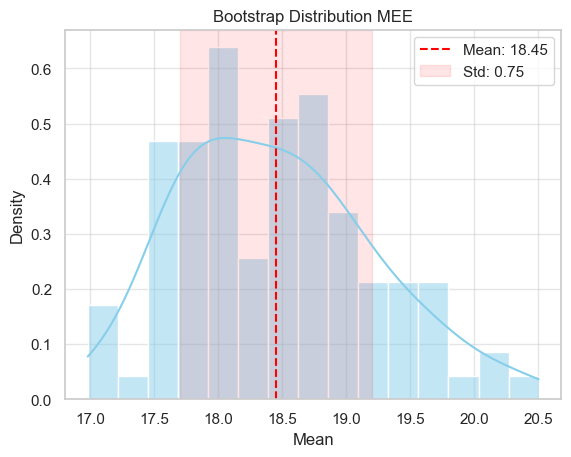

In [16]:
cr.plot_bootstrap_distribution([metric[default_metric] for metric in bootstrap_scores], title=f"Bootstrap Distribution {default_metric.upper()}")

<h2>Internal Test predictions</h2>
<hr/>

In [19]:
fitted_model = non_nested_runner.fitted_model(X_tr, y_tr)

y_pred_tr = non_nested_runner.predict(fitted_model, X_tr)
y_pred_internal = non_nested_runner.predict(
    fitted_model,
    X_internal_ts,
)

mee_tr = cr.mee(y_tr, y_pred_tr)
mee_internal = cr.mee(y_internal_ts, y_pred_internal)

print(f"Training MEE:      {mee_tr:.4f}")
print(f"Internal Test MEE: {mee_internal:.4f}")


Training MEE:      0.2599
Internal Test MEE: 18.1632


<hr/>